# Assessing non-Markovianity
## MPILMBB EEG microstate sequences

**Aim:**
Test whether resting-state EEG microstate sequences from the MPILMBB dataset are
consistent with a first-order Markov chain, using the classical likelihood-ratio test
battery of Kullback (1962).

**Method:**
For each subject (n=201, `smoothing='b1'` EC recordings) we test:

1. **Markov order** (`mstsa.test_markov0/1/2`): is the sequence i.i.d. (0th order),
   is a first-order model sufficient, or is a second-order model needed?
2. **Sojourn-time geometricity** (`mstsa.test_geometric_seq`): a first-order Markov
   chain implies geometrically-distributed dwell times in each state; non-geometric
   dwell times are a hallmark of non-Markovian dynamics.

All p-values are FDR-corrected (Benjamini-Hochberg, `mstsa.multiple_comparisons`)
across the n=201 subjects (or subject x state pairs) within each test family, and we
report the proportion of subjects for which the corresponding null hypothesis is
rejected at alpha=0.05.

Computation and plotting are kept in separate cells throughout, and every
computation cell caches its results to disk under `../data/cache/nonmarkovianity*`
(loading from cache if present). Since `jupyter nbconvert --execute` always re-runs a
notebook from scratch (there is no partial re-execution), this is what actually makes
"separate computation and plotting cells" pay off: a plot-only edit (colors, style,
CI markers, ...) triggers a full top-to-bottom re-run, but every computation cell
short-circuits to its cached `.npz` file instead of repeating the underlying
statistical tests or simulations, so only the fast plotting cell actually does new
work. Delete the corresponding cache file (or change `smoothing`) to force a
recompute.

*Note:* an earlier version of this notebook also tested time-reversal symmetry /
detailed balance (`test_symmetry`, `detailed_balance`) and stationarity
(`test_cond_homogeneity`, `test_j_homogeneity`, `test_jk_homogeneity`) as a control.
Those sections were removed from the live pipeline, but their results are still on
disk in `figures/nonmarkovianity_detailed_balance.png` and
`figures/nonmarkovianity_stationarity.png` for reference: notably, marginal and joint
homogeneity were rejected in ~99% and ~98.5% of subjects, meaning the sequences are
themselves non-stationary -- so the 100% rejection rate on the Markov-order tests
below cannot be attributed to non-Markovianity in isolation.

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import mstsa

print(mstsa.__version__)

0.4.0


In [2]:
data_path = "../data/mpilmbb"

# Smoothing (pre-processing) condition to analyze: one of 'b1', 'b3', 'b9', 'ip', or
# 'all' to pool every condition together.
smoothing = 'b1'
_SMOOTHING_CHOICES = ('b1', 'b3', 'b9', 'ip', 'all')
if smoothing not in _SMOOTHING_CHOICES:
    raise ValueError(f"smoothing must be one of {_SMOOTHING_CHOICES}, got {smoothing!r}")

pattern = "*_EC_*.npy" if smoothing == 'all' else f"*_EC_ms_{smoothing}_K4_*.npy"
files = sorted(glob.glob(f"{data_path}/{pattern}"))
print(f"smoothing={smoothing!r}: {len(files)} EC files")

alpha = 0.05
K_states = 4  # MPILMBB microstate maps A-D

smoothing='b1': 201 EC files


## Markov order (0th / 1st / 2nd)

`test_markov0` tests the i.i.d. (order-0) null; `test_markov1` tests whether a
first-order model is *sufficient* (i.e. whether two-step transitions are consistent
with one-step transitions); `test_markov2` tests whether a *second*-order model is
needed beyond first order. All three are likelihood-ratio (G) tests against a
chi-squared null (Kullback, 1962).

In [ ]:
cache_dir = "../data/cache/nonmarkovianity"
os.makedirs(cache_dir, exist_ok=True)
cache_file_order = os.path.join(cache_dir, f"order_tests_{smoothing}.npz")

if os.path.exists(cache_file_order):
    d = np.load(cache_file_order)
    p_markov0 = d['p_markov0']
    p_markov1 = d['p_markov1']
    p_markov2 = d['p_markov2']
    print(f"loaded cached Markov order test results from {cache_file_order}")
else:
    p_markov0 = np.zeros(len(files))
    p_markov1 = np.zeros(len(files))
    p_markov2 = np.zeros(len(files))

    for i, f in enumerate(files):
        x = np.load(f)
        K = len(set(x))
        p_markov0[i] = mstsa.test_markov0(x, K)
        p_markov1[i] = mstsa.test_markov1(x, K)
        p_markov2[i] = mstsa.test_markov2(x, K)
        print(f"[{i+1}/{len(files)}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    np.savez(cache_file_order, 
             p_markov0=p_markov0, 
             p_markov1=p_markov1, 
             p_markov2=p_markov2)

p_markov0_fdr = mstsa.multiple_comparisons(p_markov0, method='fdr_bh')
p_markov1_fdr = mstsa.multiple_comparisons(p_markov1, method='fdr_bh')
p_markov2_fdr = mstsa.multiple_comparisons(p_markov2, method='fdr_bh')

frac_reject0 = np.mean(p_markov0_fdr < alpha)
frac_reject1 = np.mean(p_markov1_fdr < alpha)
frac_reject2 = np.mean(p_markov2_fdr < alpha)
print(f"reject i.i.d. (order 0):    {frac_reject0 * 100:5.1f}% of subjects (FDR)")
print(f"reject order-1 sufficiency: {frac_reject1 * 100:5.1f}% of subjects (FDR)")
print(f"reject order-2 sufficiency: {frac_reject2 * 100:5.1f}% of subjects (FDR)")

loaded cached Markov order test results from ../data/cache/nonmarkovianity/order_tests_b1.npz
reject i.i.d. (order 0):    100.0% of subjects (FDR-corrected)
reject order-1 sufficiency: 100.0% of subjects (FDR-corrected)
reject order-2 sufficiency: 100.0% of subjects (FDR-corrected)


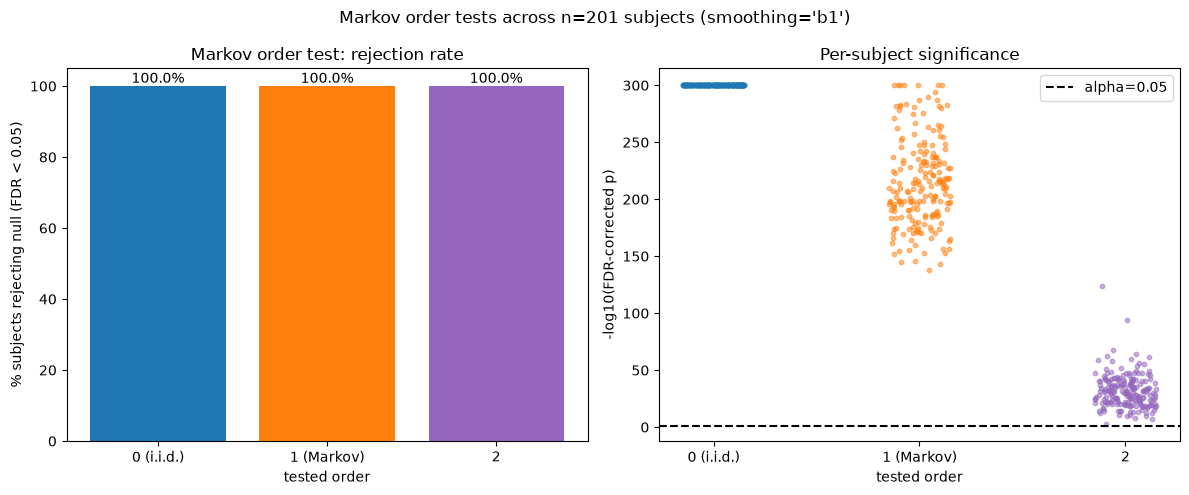

In [ ]:
def _neglog10p(p):
    return -np.log10(np.clip(p, 1e-300, 1.0))


order_labels = ['0 (i.i.d.)', '1 (Markov)', '2']
order_fracs = [frac_reject0 * 100, frac_reject1 * 100, frac_reject2 * 100]
order_colors = ['tab:blue', 'tab:orange', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(order_labels, order_fracs, color=order_colors)
axes[0].set_ylim(0, 105)
axes[0].set_xlabel('tested order')
axes[0].set_ylabel('% subjects rejecting null (FDR < 0.05)')
axes[0].set_title('Markov order test: rejection rate')
for lab, frac in zip(order_labels, order_fracs):
    axes[0].annotate(f"{frac:.1f}%", (lab, frac), ha='center', va='bottom')

rng = np.random.default_rng(0)
for j, (p_fdr, color) in enumerate(zip([p_markov0_fdr, 
                                        p_markov1_fdr, 
                                        p_markov2_fdr], order_colors)):
    y = _neglog10p(p_fdr)
    jitter = rng.uniform(-0.15, 0.15, size=len(y))
    axes[1].scatter(np.full(len(y), j) + jitter, y, s=10, color=color, alpha=0.5)
axes[1].axhline(-np.log10(alpha), color='k', ls='--', label=f'alpha={alpha}')
axes[1].set_xticks(range(len(order_labels)))
axes[1].set_xticklabels(order_labels)
axes[1].set_xlabel('tested order')
axes[1].set_ylabel('-log10(FDR-corrected p)')
axes[1].set_title('Per-subject significance')
axes[1].legend()

fig.suptitle(f'Markov order tests across n={len(files)} subjects '
             f'(smoothing={smoothing!r})')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/nonmarkovianity_order_tests.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## Sojourn-time geometricity

A first-order (memoryless) Markov chain implies that the sojourn time in each state
follows a geometric distribution. `mstsa.test_geometric_seq` compares the observed
dwell-time histogram of each microstate against a fitted geometric distribution.

In [5]:
cache_file_geom = os.path.join(cache_dir, f"geometricity_{smoothing}.npz")

if os.path.exists(cache_file_geom):
    p_geom = np.load(cache_file_geom)['p_geom']
    print(f"loaded cached sojourn-time geometricity results from {cache_file_geom}")
else:
    p_geom = np.full((len(files), K_states), np.nan)

    for i, f in enumerate(files):
        x = np.load(f)
        K = len(set(x))
        p_geom[i, :K] = mstsa.test_geometric_seq(x, K, verbose=False)
        print(f"[{i+1}/{len(files)}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    np.savez(cache_file_geom, p_geom=p_geom)

valid = np.isfinite(p_geom)
p_geom_fdr = np.full_like(p_geom, np.nan)
p_geom_fdr[valid] = mstsa.multiple_comparisons(p_geom[valid], method='fdr_bh')

frac_reject_geom = np.nanmean(p_geom_fdr < alpha, axis=0)
for k in range(K_states):
    print(f"state {k}: {frac_reject_geom[k] * 100:5.1f}% of subjects reject geometric "
          f"dwell times (FDR-corrected)")

loaded cached sojourn-time geometricity results from ../data/cache/nonmarkovianity/geometricity_b1.npz
state 0:   0.0% of subjects reject geometric dwell times (FDR-corrected)
state 1:   0.0% of subjects reject geometric dwell times (FDR-corrected)
state 2:  19.9% of subjects reject geometric dwell times (FDR-corrected)
state 3:  25.4% of subjects reject geometric dwell times (FDR-corrected)


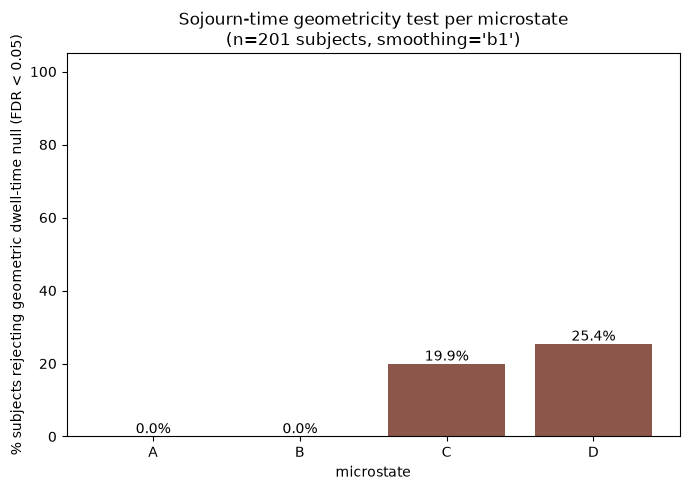

In [6]:
geom_labels = ['A', 'B', 'C', 'D'][:K_states]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(geom_labels, frac_reject_geom * 100, color='tab:brown')
ax.set_ylim(0, 105)
ax.set_xlabel('microstate')
ax.set_ylabel('% subjects rejecting geometric dwell-time null (FDR < 0.05)')
ax.set_title(f'Sojourn-time geometricity test per microstate\n'
             f'(n={len(files)} subjects, smoothing={smoothing!r})')
for lab, frac in zip(geom_labels, frac_reject_geom * 100):
    ax.annotate(f"{frac:.1f}%", (lab, frac), ha='center', va='bottom')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/nonmarkovianity_geometric_dwell.png', dpi=150, bbox_inches='tight')
plt.show()

## Auto- and partial auto-information functions (AIF / PAIF)

`mstsa.aif` computes the auto-information function -- the time-lagged mutual
information `I(X_t; X_{t+k})` -- and `mstsa.paif` computes the partial
auto-information function, which removes the contribution of shorter lags (analogous
to a partial autocorrelation function). Both are lag-resolved, continuous measures of
memory in the sequence, complementing the categorical Markov-order tests above: for a
truly first-order-Markov process, PAIF should vanish beyond lag 1, while residual
dependence at longer lags indicates non-Markovian structure.

We compute AIF up to lag 99 (`kmax=100`) and PAIF up to lag 6 (`kmax=7`), and compare
the real data against a **first-order Markov surrogate confidence interval**: for
each subject, `n_surr` surrogates are generated from that subject's own transition
matrix (`mstsa.mc_sample_path`), and AIF/PAIF are computed on each. The 95%
confidence band is the [2.5, 97.5] percentile of the pooled surrogate values at each
lag; real AIF/PAIF values outside this band indicate memory that a first-order Markov
model cannot account for.

AIF is far more expensive than the other measures used in this notebook (~4.5 s per
call at `kmax=100`, vs. ~1.6 s for all three Markov-order tests combined, or <0.1 s
for PAIF/geometricity/order tests) -- computing it on the full n=201 cohort with
enough surrogates for a stable confidence band would take well over an hour. We
therefore use a random subset of `n_subset=30` subjects (fixed seed) with `n_surr=5`
surrogates each.

In [7]:
kmax_aif = 100
kmax_paif = 7
n_subset = 30
n_surr = 5

cache_dir = "../data/cache/nonmarkovianity_aif"
cache_file = os.path.join(cache_dir, f"aif_paif_{smoothing}_n{n_subset}_s{n_surr}.npz")
os.makedirs(cache_dir, exist_ok=True)

if os.path.exists(cache_file):
    d = np.load(cache_file)
    aif_real, aif_surr = d['aif_real'], d['aif_surr']
    paif_real, paif_surr = d['paif_real'], d['paif_surr']
    print(f"loaded cached AIF/PAIF results from {cache_file}")
else:
    rng = np.random.default_rng(0)
    subset_idx = rng.choice(len(files), size=n_subset, replace=False)
    subset_files = [files[i] for i in subset_idx]

    aif_real = np.zeros((n_subset, kmax_aif))
    aif_surr = np.zeros((n_subset, n_surr, kmax_aif))

    paif_real = np.zeros((n_subset, kmax_paif))
    paif_surr = np.zeros((n_subset, n_surr, kmax_paif))

    for i, f in enumerate(subset_files):
        x = np.load(f)
        K = len(set(x))

        aif_real[i] = mstsa.aif(x, K, kmax=kmax_aif)
        paif_real[i] = mstsa.paif(x, K, kmax=kmax_paif)

        T = mstsa.tpm_cond(x, K)
        p = mstsa.pmf(x, K)
        for s in range(n_surr):
            surr = mstsa.mc_sample_path(T=T, n=len(x), p=p)
            aif_surr[i, s] = mstsa.aif(surr, K, kmax=kmax_aif)
            paif_surr[i, s] = mstsa.paif(surr, K, kmax=kmax_paif)

        print(f"[{i+1}/{n_subset}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    np.savez(cache_file, aif_real=aif_real, aif_surr=aif_surr,
              paif_real=paif_real, paif_surr=paif_surr)

aif_real_mean = aif_real.mean(axis=0)
aif_surr_pool = aif_surr.reshape(-1, kmax_aif)  # (n_subset * n_surr, kmax_aif)
aif_ci_lo, aif_ci_hi = np.percentile(aif_surr_pool, [2.5, 97.5], axis=0)

paif_real_mean = paif_real.mean(axis=0)
paif_surr_pool = paif_surr.reshape(-1, kmax_paif)
paif_ci_lo, paif_ci_hi = np.percentile(paif_surr_pool, [2.5, 97.5], axis=0)

lags_aif = np.arange(kmax_aif)
lags_paif = np.arange(kmax_paif)

n_out_aif = np.sum((aif_real_mean < aif_ci_lo) | (aif_real_mean > aif_ci_hi))
n_out_paif = np.sum((paif_real_mean < paif_ci_lo) | (paif_real_mean > paif_ci_hi))
print(f"AIF:  {n_out_aif}/{kmax_aif} lags where the group-mean real AIF falls outside "
      f"the surrogate 95% CI")
print(f"PAIF: {n_out_paif}/{kmax_paif} lags where the group-mean real PAIF falls "
      f"outside the surrogate 95% CI")

loaded cached AIF/PAIF results from ../data/cache/nonmarkovianity_aif/aif_paif_b1_n30_s5.npz
AIF:  43/100 lags where the group-mean real AIF falls outside the surrogate 95% CI
PAIF: 5/7 lags where the group-mean real PAIF falls outside the surrogate 95% CI


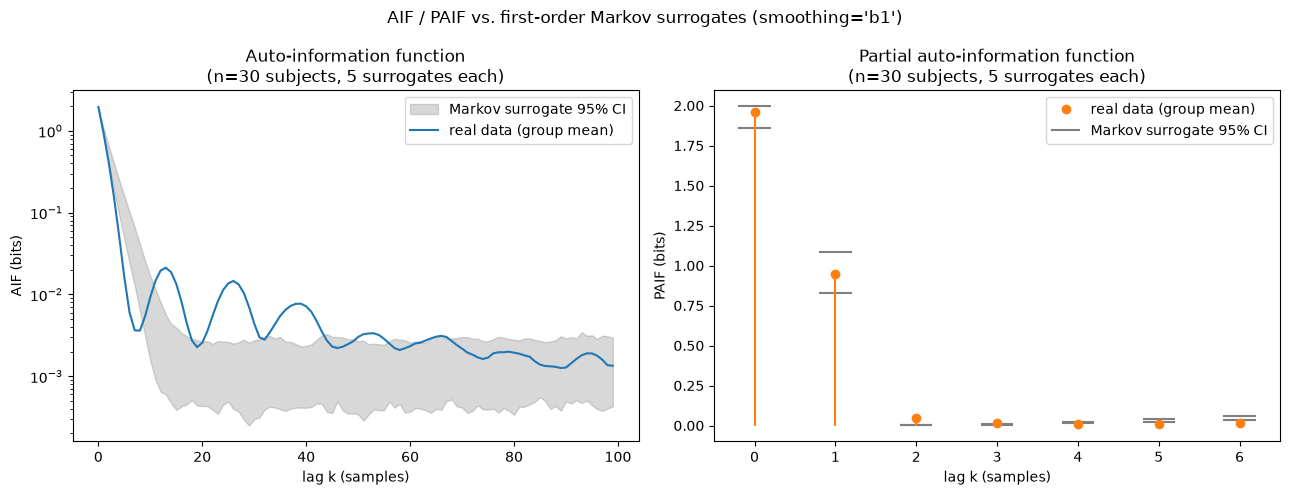

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].fill_between(lags_aif, aif_ci_lo, aif_ci_hi, color='tab:gray', alpha=0.3,
                      label='Markov surrogate 95% CI')
axes[0].plot(lags_aif, aif_real_mean, color='tab:blue', lw=1.5, label='real data (group mean)')
axes[0].set_yscale('log')
axes[0].set_xlabel('lag k (samples)')
axes[0].set_ylabel('AIF (bits)')
axes[0].set_title(f'Auto-information function\n(n={n_subset} subjects, {n_surr} surrogates each)')
axes[0].legend()

markerline, stemlines, baseline = axes[1].stem(lags_paif, paif_real_mean, basefmt=' ')
plt.setp(markerline, color='tab:orange', markersize=6, zorder=3)
plt.setp(stemlines, color='tab:orange', linewidth=1.5, zorder=3)
cap_halfwidth = 0.2
for k in lags_paif:
    axes[1].hlines([paif_ci_lo[k], paif_ci_hi[k]], k - cap_halfwidth, k + cap_halfwidth,
                    color='tab:gray', linewidth=1.5, zorder=2)
axes[1].set_xlabel('lag k (samples)')
axes[1].set_ylabel('PAIF (bits)')
axes[1].set_xticks(lags_paif)
axes[1].set_xlim(-0.5, kmax_paif - 0.5)
axes[1].set_title(f'Partial auto-information function\n(n={n_subset} subjects, {n_surr} surrogates each)')
axes[1].legend(handles=[markerline, plt.Line2D([0], [0], color='tab:gray', lw=1.5)],
               labels=['real data (group mean)', 'Markov surrogate 95% CI'])

fig.suptitle(f'AIF / PAIF vs. first-order Markov surrogates (smoothing={smoothing!r})')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/nonmarkovianity_aif_paif.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Collects the FDR-corrected rejection rate of every null hypothesis tested above into
one figure.

As noted at the top of the notebook, a stationarity control run previously showed
that marginal and joint homogeneity are rejected in ~99% and ~98.5% of subjects
(see `figures/nonmarkovianity_stationarity.png`), so the 100% rejection rate on all
three Markov-order tests below cannot be attributed to non-Markovianity in isolation
-- it is consistent with (and may be partly or wholly driven by) genuine
non-stationarity of the transition structure. The sojourn-time results are
comparatively less confounded by this, since they are more localized in time, and
show partial, state-dependent deviations from the first-order-Markov prediction
rather than a uniform rejection.

In [9]:
summary_labels = [
    'i.i.d. (order 0)',
    'order 1 (Markov) insufficient',
    'order 2 insufficient',
    'non-geometric dwell times (A)',
    'non-geometric dwell times (B)',
    'non-geometric dwell times (C)',
    'non-geometric dwell times (D)',
]
summary_fracs = [
    frac_reject0 * 100, frac_reject1 * 100, frac_reject2 * 100,
    *(frac_reject_geom * 100),
]
summary_colors = [
    'tab:blue', 'tab:orange', 'tab:purple',
    'tab:brown', 'tab:brown', 'tab:brown', 'tab:brown',
]

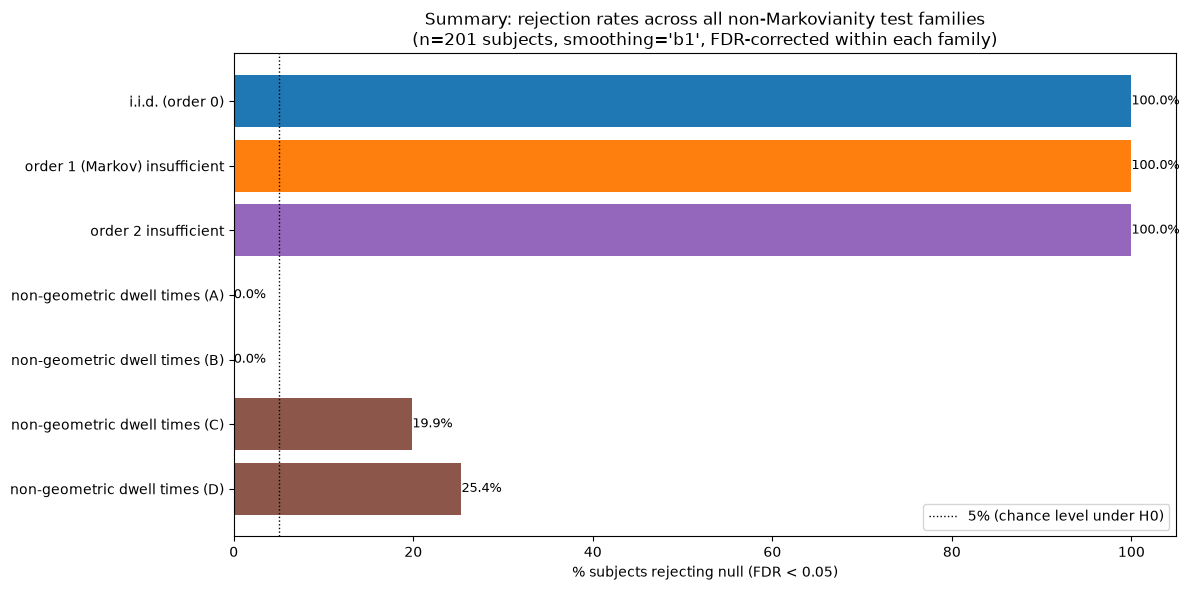

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(summary_labels))
ax.barh(y, summary_fracs, color=summary_colors)
ax.set_yticks(y)
ax.set_yticklabels(summary_labels)
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.set_xlabel('% subjects rejecting null (FDR < 0.05)')
for yi, frac in zip(y, summary_fracs):
    ax.annotate(f"{frac:.1f}%", (frac, yi), va='center', ha='left', fontsize=9)
ax.axvline(5, color='k', ls=':', lw=1, label='5% (chance level under H0)')
ax.legend(loc='lower right')
ax.set_title(f'Summary: rejection rates across all non-Markovianity test families\n'
             f'(n={len(files)} subjects, smoothing={smoothing!r}, FDR-corrected within each family)')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/nonmarkovianity_summary.png', dpi=150, bbox_inches='tight')
plt.show()